
## Authorship

- **Course / code author:** Xinze Li  
- **Review article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



In [ ]:
# Intentionally empty (kept for section separation).


## Preliminary if Using Google Colab

- Recommended method: use `pip` with `requirements.txt` at the repository root.
- If you are in **Google Colab**, run the next code cell once to clone this repo and install dependencies.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/XinzeLee/Fundamentals_of_AI_for_PE/blob/main/2_Classic_ML/gaussian_process_bayesian_optimization.ipynb)


In [ ]:

import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_dir = "/content/Fundamentals_of_AI_for_PE"
    if not os.path.isdir(repo_dir):
        !git clone https://github.com/XinzeLee/Fundamentals_of_AI_for_PE.git /content/Fundamentals_of_AI_for_PE
    %cd /content/Fundamentals_of_AI_for_PE
    !pip install -q -r requirements.txt
    os.chdir(os.path.join(repo_dir, "2_Classic_ML"))
else:
    print(
        "Not in Google Colab — skip clone/pip. Use your local env or run: pip install -r requirements.txt from the repo root."
    )


In [ ]:
# Intentionally empty (kept for section separation).


# Gaussian process regression and Bayesian optimization (California housing)

This notebook introduces two connected ideas used often in **surrogate modeling** and **expensive optimization**—relevant when simulations or lab measurements are costly (e.g. converter loss maps, efficiency surfaces, or reliability metrics):

1. **Gaussian process (GP) regression** — a nonparametric model that predicts a mean and an **uncertainty (posterior variance)** at each input.
2. **Bayesian optimization (BO)** — sequentially chooses hyperparameters (or design parameters) using a surrogate and an **acquisition function** such as **expected improvement**.

We use `sklearn.datasets.fetch_california_housing` (8-D regression) and keep training subsets modest so GP fits remain tractable ($\mathcal{O}(n^3)$ in the exact formulation used here).


In [ ]:
# Intentionally empty (kept for section separation).


## 1. Gaussian process regression — idea in one minute

A GP treats the unknown function $f(\mathbf{x})$ as drawn from a **distribution over functions**, specified by a **mean** (often zero after centering $y$) and a **kernel** $k(\mathbf{x}, \mathbf{x}')$ that says how correlated outputs are when inputs are similar.

Given training pairs $\{(\mathbf{x}_i, y_i)\}$, the posterior at a new $\mathbf{x}_*$ is Gaussian with closed-form mean and variance. That variance is key: it grows **away from data**, so the model knows what it does not know—unlike a plain neural net unless you add separate uncertainty machinery.

**Kernel hyperparameters** (signal scale, length-scales, noise) strongly affect flexibility and calibration. `GaussianProcessRegressor` can optimize them by maximizing **log marginal likelihood** (a point estimate). In **Section 3** we instead use **Bayesian optimization** over a small hyperparameter box to mimic workflows where inner optimization is unreliable or you want a global search.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X, y = fetch_california_housing(return_X_y=True)
# 60% train / 20% validation (for BO objective) / 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s = scaler_X.transform(X_val)
X_test_s = scaler_X.transform(X_test)

# GP cost ~ O(n^3); subsample training for demos (indices fixed for reproducibility)
N_GP_TRAIN = min(1200, X_train_s.shape[0])
sub_idx = np.random.default_rng(RANDOM_STATE).choice(X_train_s.shape[0], size=N_GP_TRAIN, replace=False)
X_gptr = X_train_s[sub_idx]
y_gptr = y_train[sub_idx]

print(f"Samples: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}; GP fit uses n={N_GP_TRAIN}")


Samples: train=12384, val=4128, test=4128; GP fit uses n=1200



## 2. Fit a GP with default kernel + marginal-likelihood optimization

`GaussianProcessRegressor` places a **ConstantKernel $\times$ RBF** prior by default and tunes kernel parameters with L-BFGS on the **log marginal likelihood**. We evaluate **RMSE**, **MAE**, and **$R^2$** on the held-out test set and plot **predicted vs. actual** and **residuals**.


GP (marginal likelihood / default routine)
  Test RMSE: 0.8457  MAE: 0.6073  R2: 0.4542
  Learned kernel: 1.04**2 * RBF(length_scale=0.429)


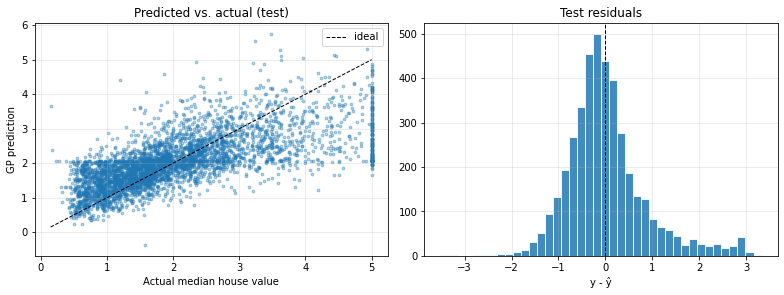

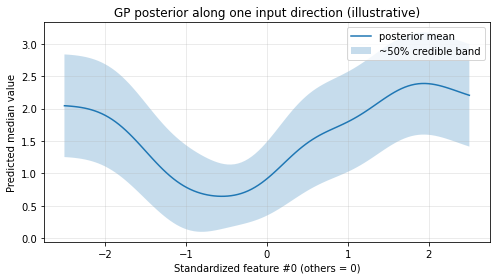

In [2]:

# Define the kernel: ConstantKernel * RBF, with bounds for hyperparameter search
kernel_mle = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the GaussianProcessRegressor instance, with marginal likelihood optimization for kernel params
gpr_mle = GaussianProcessRegressor(
    kernel=kernel_mle,
    alpha=1e-6,  # Additive noise (jitter/regularization)
    normalize_y=True,  # Normalize targets internally
    n_restarts_optimizer=2,  # Number of optimizer restarts for kernel parameter tuning
    random_state=RANDOM_STATE,  # Ensure reproducibility
)

# Fit the GP model on the selected (subsampled) training set
gpr_mle.fit(X_gptr, y_gptr)

# Predict on the standardized test set using the trained GP
y_test_pred_mle = gpr_mle.predict(X_test_s)

# Calculate regression metrics: RMSE, MAE, R^2
rmse_mle = mean_squared_error(y_test, y_test_pred_mle) ** 0.5
mae_mle = mean_absolute_error(y_test, y_test_pred_mle)
r2_mle = r2_score(y_test, y_test_pred_mle)

# Print the test results and the learned kernel after marginal likelihood optimization
print("GP (marginal likelihood / default routine)")
print(f"  Test RMSE: {rmse_mle:.4f}  MAE: {mae_mle:.4f}  R2: {r2_mle:.4f}")
print(f"  Learned kernel: {gpr_mle.kernel_}")

# --- Plot predicted vs actual and residuals ---

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# Scatter plot: predicted vs. actual (should follow y=x line for ideal predictions)
ax[0].scatter(y_test, y_test_pred_mle, s=8, alpha=0.35, c="C0")
lims = [y_test.min(), y_test.max()]  # Limits for y=x line
ax[0].plot(lims, lims, "k--", lw=1, label="ideal")  # y = x reference line
ax[0].set_xlabel("Actual median house value")
ax[0].set_ylabel("GP prediction")
ax[0].set_title("Predicted vs. actual (test)")
ax[0].legend()

# Residuals: histogram of (actual - predicted) on the test set
res = y_test - y_test_pred_mle
ax[1].hist(res, bins=40, color="C0", edgecolor="white", alpha=0.85)
ax[1].axvline(0.0, color="k", ls="--", lw=1)  # Reference at zero error
ax[1].set_title("Test residuals")
ax[1].set_xlabel("y - ŷ")

plt.tight_layout()
plt.show()

# --- Uncertainty visualization on a one-dimensional standardized feature slice ---

# Index of feature to vary (all others held at mean=0 in standardized space)
j = 0
grid = np.linspace(-2.5, 2.5, 120)  # Range of standardized values to scan

# Create a grid along this feature, all others = 0
X_line = np.zeros((len(grid), X_gptr.shape[1]))
X_line[:, j] = grid  # Vary only feature j

# Predict posterior mean and standard deviation on this slice
mu_s, std_s = gpr_mle.predict(X_line, return_std=True)

fig, ax = plt.subplots(figsize=(7, 4))

# Plot posterior mean along the 1D slice
ax.plot(grid, mu_s, label="posterior mean")

# Fill 50% credible band (~0.674 σ for normal)
ax.fill_between(
    grid, mu_s - 0.674 * std_s, mu_s + 0.674 * std_s,
    alpha=0.25, label="~50% credible band"
)
ax.set_xlabel(f"Standardized feature #{j} (others = 0)")
ax.set_ylabel("Predicted median value")
ax.set_title("GP posterior along one input direction (illustrative)")
ax.legend()
plt.tight_layout()
plt.show()



## 3. Bayesian optimization for GP hyperparameters

**Goal:** choose scalar hyperparameters $(\sigma^2_f, \ell, \alpha)$ of a **fixed structural** kernel

$$
k(\mathbf{x}, \mathbf{x}') = \sigma^2_f \exp\left(-\frac{\|\mathbf{x}-\mathbf{x}'\|^2}{2\ell^2}\right)
$$

with **observation noise** $\alpha$ (passed as `GaussianProcessRegressor(..., alpha=alpha)`), so validation **RMSE** is low.

**Why BO?** The validation loss is a **black box** in the hyperparameters: noisy, possibly multimodal, and each evaluation retrains a GP. BO fits a **cheap surrogate** (here, another GP) over the log-hyperparameter space and picks the next trial by **expected improvement (EI)**—balancing **exploitation** (low surrogate mean) and **exploration** (high surrogate uncertainty).

**Loop:** evaluate RMSE at new $\theta$; refit the surrogate on all $(\theta, \mathrm{RMSE})$ pairs; maximize EI over a random candidate pool to pick $\theta_{\mathrm{next}}$; repeat.

We log **best RMSE so far** each iteration and plot an **EI slice** and **surrogate mean** over two hyperparameters (fixing the third at the BO best) after the run.

**Implementation note:** each inner `GaussianProcessRegressor` uses `optimizer=None` so its kernel stays exactly at the candidate $(\sigma^2_f, \ell, \alpha)$ chosen by BO. Otherwise `sklearn` would still run an internal L-BFGS marginal-likelihood step and blur the meaning of “fixed” hyperparameters.


Iteration  1/50: best RMSE so far = 0.63421  (latest tried: signal=3.24, length-scale=3.13, alpha=2.85e-06)
Iteration  5/50: best RMSE so far = 0.63421  (latest tried: signal=20.7, length-scale=0.651, alpha=6.29e-04)
Iteration 10/50: best RMSE so far = 0.62107  (latest tried: signal=27.6, length-scale=3.08, alpha=1.95e-02)
Iteration 15/50: best RMSE so far = 0.62107  (latest tried: signal=3.82, length-scale=0.182, alpha=1.05e-06)
Iteration 20/50: best RMSE so far = 0.60759  (latest tried: signal=0.105, length-scale=0.0342, alpha=1.27e-04)
Iteration 25/50: best RMSE so far = 0.60759  (latest tried: signal=6.41, length-scale=0.15, alpha=3.15e-02)
Iteration 30/50: best RMSE so far = 0.60759  (latest tried: signal=0.11, length-scale=0.215, alpha=1.15e-06)
Iteration 35/50: best RMSE so far = 0.60759  (latest tried: signal=0.101, length-scale=2.85, alpha=1.96e-04)
Iteration 40/50: best RMSE so far = 0.60759  (latest tried: signal=0.34, length-scale=2.36, alpha=1.09e-02)
Iteration 45/50: best

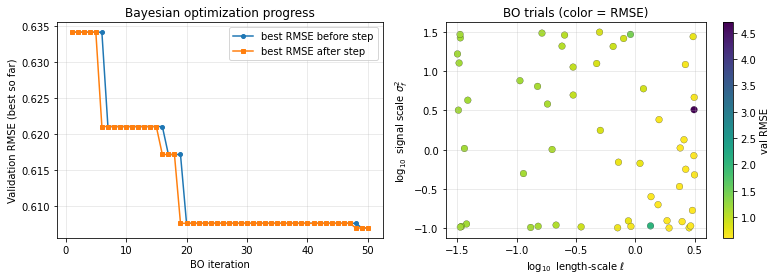

Best BO hyperparameters (validation):
  signal scale=0.1996, length_scale=1.556, alpha=0.0194
  best validation RMSE: 0.6069

===== FINAL OPTIMIZED HYPERPARAMETERS (from Bayesian Optimization) =====
Signal scale (sigma^2_f): 0.199605
Length scale (ell):       1.555676
Alpha (noise):            1.939561e-02


Test RMSE (MLE-style default routine): 0.8457
Test RMSE (BO-selected hyperparameters): 0.6096


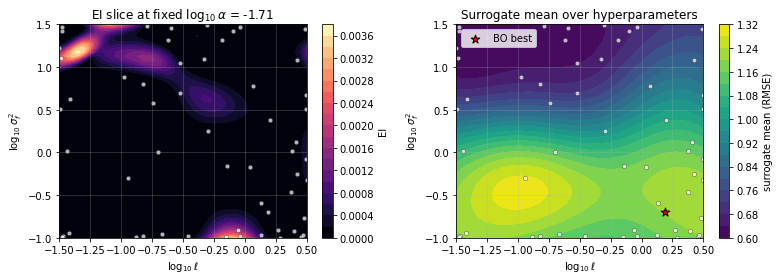

In [3]:
# --- Objective Function: Validation RMSE for GP hyperparameters ---
def gpr_val_rmse(const_scale, length_scale, alpha_noise):
    """
    Train a Gaussian Process regressor with specified kernel hyperparameters,
    then return the validation RMSE (Root Mean Squared Error).
    
    This is the black-box objective function optimized by Bayesian optimization.
    It is expensive since each evaluation trains a new GP and predicts on a validation set.
    
    Parameters
    ----------
    const_scale : float
        Signal/constant (sigma^2_f) kernel variance parameter.
    length_scale : float
        RBF length scale (ell) kernel parameter.
    alpha_noise : float
        Observation noise alpha (regularization term).
    
    Returns
    -------
    float
        Validation RMSE for this choice of hyperparameters.
    """
    # Define the kernel with fixed hyperparameters (bounds singletoned)
    k = C(float(const_scale), (float(const_scale), float(const_scale))) * RBF(
        float(length_scale), (float(length_scale), float(length_scale))
    )
    # Build the GP model (kernel fixed; no optimizer step)
    model = GaussianProcessRegressor(
        kernel=k,
        alpha=float(alpha_noise),
        normalize_y=True,
        optimizer=None,                 # disables marginal likelihood refitting!
        random_state=RANDOM_STATE,
    )
    model.fit(X_gptr, y_gptr)          # fit on training data
    pred = model.predict(X_val_s)      # predict on validation set
    return mean_squared_error(y_val, pred) ** 0.5

# --- Acquisition Function: Expected Improvement ---
def expected_improvement(mu, sigma, f_best):
    """
    Compute the Expected Improvement (EI) acquisition function for BO.
    Used to select the next point to evaluate by balancing exploitation and exploration.
    For minimization: f_best = current best (lowest) observed objective.
    
    Parameters
    ----------
    mu : np.ndarray
        Surrogate (GP) mean predictions for candidate points.
    sigma : np.ndarray
        Surrogate (GP) standard deviations for candidate points.
    f_best : float
        Best (lowest) objective value observed so far.
    
    Returns
    -------
    np.ndarray
        EI values for each candidate.
    """
    sigma = np.asarray(sigma).ravel()
    sigma = np.maximum(sigma, 1e-9)        # avoid division by zero
    imp = f_best - mu                      # improvement if better than best so far
    z = imp / sigma                        # standardized improvement
    return imp * norm.cdf(z) + sigma * norm.pdf(z)

# --- Hyperparameter Search Space (log10 space): [const, length, alpha] ---
BOUNDS = np.array([[-1.0, 1.5],    # log10(signal/const variance)
                   [-1.5, 0.5],    # log10(length scale)
                   [-6.0, -1.5]])  # log10(alpha)

# --- Helper: convert log10 params to original scale ---
def decode(theta_log):
    """
    Convert vector of log10 hyperparams to original scale.
    theta_log: [log10(const), log10(length), log10(alpha)]
    Returns: (const, length, alpha) in real scale.
    """
    return 10.0 ** theta_log[0], 10.0 ** theta_log[1], 10.0 ** theta_log[2]

# --- Helper: sample n random vectors in the search box (log space) ---
def random_in_box(rng, n):
    """
    Sample n points uniformly at random from the search region [log10].
    """
    return rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(n, 3))

# --- Bayesian Optimization main loop parameters ---
N_INIT = 6       # number of random initial points
N_BO = 50        # number of BO iterations
rng = np.random.default_rng(RANDOM_STATE + 1)  # RNG for reproducibility

Theta = []       # Store all sampled hyperparameter vectors
Y_rmse = []      # Store corresponding objective values (validation RMSEs)

# --- 1. INITIALIZE: Evaluate a handful of random starting points
T0 = random_in_box(rng, N_INIT)               # initial random points in log space
for t in T0:
    Theta.append(t)
    c, l, a = decode(t)
    Y_rmse.append(gpr_val_rmse(c, l, a))      # compute & store validation RMSE

Theta = np.asarray(Theta)
Y_rmse = np.asarray(Y_rmse)

history_best = []     # Track best RMSE before each step
best_trace = []       # Track best RMSE after each step
sur = None            # Placeholder for last surrogate
theta_scaler = None   # Store feature scaler for log-theta

# --- 2. BAYESIAN OPTIMIZATION MAIN LOOP ---
for it in range(N_BO):
    f_best = Y_rmse.min()                     # current best observed RMSE
    history_best.append(f_best)
    
    # --- Fit surrogate GP over the observed (log10) hyperparams
    theta_scaler = StandardScaler()
    Tn = theta_scaler.fit_transform(Theta)    # scale for GP stability
    sur_kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # flexible surrogate kernel
    sur = GaussianProcessRegressor(
        kernel=sur_kernel,
        alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=1,
        random_state=RANDOM_STATE + it,       # change across iterations for stability
    )
    sur.fit(Tn, Y_rmse)

    # --- Select new candidate via maximizing Expected Improvement ---
    n_cand = 2500                            # number of candidate points per iteration
    Cands = random_in_box(rng, n_cand)       # candidates for acquisition search
    Cn = theta_scaler.transform(Cands)       # transform with same scaler as training
    mu, sig = sur.predict(Cn, return_std=True)
    ei = expected_improvement(mu, sig, f_best)
    k_best = int(np.argmax(ei))              # candidate with highest EI
    t_next = Cands[k_best]                   # select its log-hyperparam vector

    # --- Evaluate the true objective at this new proposed point ---
    Theta = np.vstack([Theta, t_next])
    c, l, a = decode(t_next)
    y_new = gpr_val_rmse(c, l, a)
    Y_rmse = np.append(Y_rmse, y_new)
    best_trace.append(Y_rmse.min())          # record new best (if any)
    
    # --- Print progress every 5 iterations (and first, last) ---
    if it == 0 or (it + 1) % 5 == 0 or it == N_BO - 1:
        print(f"Iteration {it + 1:2d}/{N_BO}: best RMSE so far = {Y_rmse.min():.5f}  "
              f"(latest tried: signal={c:.3g}, length-scale={l:.3g}, alpha={a:.2e})")

# --- 3. Plot BO Results: convergence and hyperparameter search
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# Convergence trace
ax[0].plot(np.arange(1, len(history_best) + 1), history_best, "o-", ms=4, label="best RMSE before step")
ax[0].plot(np.arange(1, len(best_trace) + 1), best_trace, "s-", ms=4, label="best RMSE after step")
ax[0].set_xlabel("BO iteration")
ax[0].set_ylabel("Validation RMSE (best so far)")
ax[0].set_title("Bayesian optimization progress")
ax[0].legend()

# Scatter: all hyperparameter values tried during BO (color = val RMSE)
sc = ax[1].scatter(Theta[:, 1], Theta[:, 0], c=Y_rmse, cmap="viridis_r", s=45, ec="k", lw=0.2)
plt.colorbar(sc, ax=ax[1], label="val RMSE")
ax[1].set_xlabel(r"$\log_{10}$ length-scale $\ell$")
ax[1].set_ylabel(r"$\log_{10}$ signal scale $\sigma^2_f$")
ax[1].set_title("BO trials (color = RMSE)")
plt.tight_layout()
plt.show()

# --- 4. Find and print best BO hyperparameters (lowest validation RMSE)
idx_best = int(np.argmin(Y_rmse))
best_theta = Theta[idx_best]
c_star, l_star, a_star = decode(best_theta)
print("Best BO hyperparameters (validation):")
print(f"  signal scale={c_star:.4g}, length_scale={l_star:.4g}, alpha={a_star:.4g}")
print(f"  best validation RMSE: {Y_rmse.min():.4f}")

# --- Additional: Clear summary of final selected hyperparameters
print("\n===== FINAL OPTIMIZED HYPERPARAMETERS (from Bayesian Optimization) =====")
print(f"Signal scale (sigma^2_f): {c_star:.6f}")
print(f"Length scale (ell):       {l_star:.6f}")
print(f"Alpha (noise):            {a_star:.6e}")
print("=======================================================================\n")

# --- 5. Fit/train final GP model with BO-selected hyperparameters, report test RMSE
k_best = C(c_star, (c_star, c_star)) * RBF(l_star, (l_star, l_star))
gpr_bo = GaussianProcessRegressor(
    kernel=k_best,
    alpha=a_star,
    normalize_y=True,
    optimizer=None,
    random_state=RANDOM_STATE,
)
gpr_bo.fit(X_gptr, y_gptr)
y_test_bo = gpr_bo.predict(X_test_s)
rmse_bo = mean_squared_error(y_test, y_test_bo) ** 0.5
print(f"\nTest RMSE (MLE-style default routine): {rmse_mle:.4f}")
print(f"Test RMSE (BO-selected hyperparameters): {rmse_bo:.4f}")

# --- 6. Diagnostic plot: EI slice after BO (fixing alpha, showing const/length)
n_grid = 55
g0 = np.linspace(BOUNDS[0, 0], BOUNDS[0, 1], n_grid)    # signal/const axis (log10)
g1 = np.linspace(BOUNDS[1, 0], BOUNDS[1, 1], n_grid)    # length axis (log10)
fix_a = best_theta[2]                                   # fix alpha at BO best value (log10)
G0, G1 = np.meshgrid(g0, g1)
flat = np.column_stack([G0.ravel(), G1.ravel(), np.full(G0.size, fix_a)])    # grid of [log_const, log_length, fixed_alpha]
Tn2 = theta_scaler.transform(flat)
mu2, sig2 = sur.predict(Tn2, return_std=True)
ei2 = expected_improvement(mu2, sig2, f_best=Y_rmse.min()).reshape(n_grid, n_grid)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# Contour of EI (where next BO step would go)
cs = ax[0].contourf(G1, G0, ei2.T, levels=20, cmap="magma")
plt.colorbar(cs, ax=ax[0], label="EI")
ax[0].scatter(Theta[:, 1], Theta[:, 0], c="w", s=20, ec="k", lw=0.4, alpha=0.7)
ax[0].set_xlabel(r"$\log_{10}\ell$")
ax[0].set_ylabel(r"$\log_{10}\sigma^2_f$")
ax[0].set_title(rf"EI slice at fixed $\log_{{10}}\alpha$ = {fix_a:.2f}")

# Contour of final surrogate mean (GP model of validation RMSE)
cs2 = ax[1].contourf(G1, G0, mu2.reshape(n_grid, n_grid).T, levels=20, cmap="viridis")
plt.colorbar(cs2, ax=ax[1], label="surrogate mean (RMSE)")
ax[1].scatter(Theta[:, 1], Theta[:, 0], c="w", s=20, ec="k", lw=0.4, alpha=0.7)
ax[1].scatter([best_theta[1]], [best_theta[0]], c="r", s=80, marker="*", ec="k", zorder=5, label="BO best")
ax[1].set_xlabel(r"$\log_{10}\ell$")
ax[1].set_ylabel(r"$\log_{10}\sigma^2_f$")
ax[1].set_title("Surrogate mean over hyperparameters")
ax[1].legend()
plt.tight_layout()
plt.show()


GP (marginal likelihood / default routine)
  Test RMSE: 0.6096  MAE: 0.4293  R2: 0.7164
  Learned kernel: 0.447**2 * RBF(length_scale=1.56)


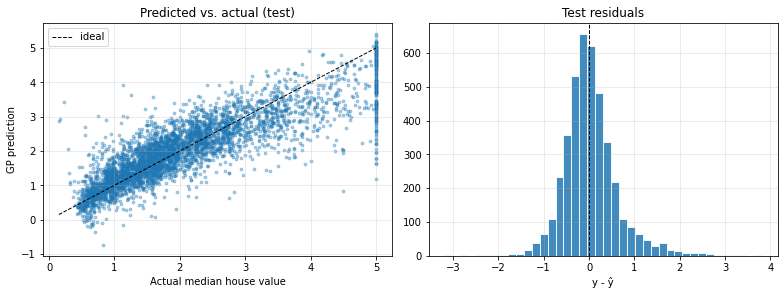

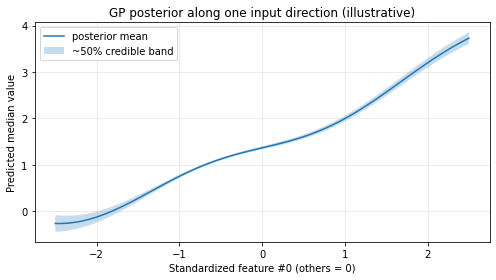

In [4]:

k_best = C(c_star, (c_star, c_star)) * RBF(l_star, (l_star, l_star))
gpr_mle = GaussianProcessRegressor(
    kernel=k_best,
    alpha=a_star,
    normalize_y=True,
    optimizer=None,
    random_state=RANDOM_STATE,
)

gpr_mle.fit(X_gptr, y_gptr)

y_test_pred_mle = gpr_mle.predict(X_test_s)
rmse_mle = mean_squared_error(y_test, y_test_pred_mle) ** 0.5
mae_mle = mean_absolute_error(y_test, y_test_pred_mle)
r2_mle = r2_score(y_test, y_test_pred_mle)

print("GP (marginal likelihood / default routine)")
print(f"  Test RMSE: {rmse_mle:.4f}  MAE: {mae_mle:.4f}  R2: {r2_mle:.4f}")
print(f"  Learned kernel: {gpr_mle.kernel_}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(y_test, y_test_pred_mle, s=8, alpha=0.35, c="C0")
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, "k--", lw=1, label="ideal")
ax[0].set_xlabel("Actual median house value")
ax[0].set_ylabel("GP prediction")
ax[0].set_title("Predicted vs. actual (test)")
ax[0].legend()

res = y_test - y_test_pred_mle
ax[1].hist(res, bins=40, color="C0", edgecolor="white", alpha=0.85)
ax[1].axvline(0.0, color="k", ls="--", lw=1)
ax[1].set_title("Test residuals")
ax[1].set_xlabel("y - ŷ")

plt.tight_layout()
plt.show()

# Uncertainty on a 1-D slice — vary one standardized feature, hold others at 0
j = 0
grid = np.linspace(-2.5, 2.5, 120)
X_line = np.zeros((len(grid), X_gptr.shape[1]))
X_line[:, j] = grid
mu_s, std_s = gpr_mle.predict(X_line, return_std=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, mu_s, label="posterior mean")
ax.fill_between(grid, mu_s - 0.674 * std_s, mu_s + 0.674 * std_s, alpha=0.25, label="~50% credible band")
ax.set_xlabel(f"Standardized feature #{j} (others = 0)")
ax.set_ylabel("Predicted median value")
ax.set_title("GP posterior along one input direction (illustrative)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Discussion: Distributional Assumptions in Bayesian Optimization

Bayesian optimization (BO) is a strategy for globally optimizing objective functions that are **expensive to evaluate** and **do not have analytical forms**. A key requirement is that the objective function is **smooth**—small input changes yield small output changes—so that a surrogate model can approximate it.

### Is the underlying distribution normal?

The standard surrogate in BO is a **Gaussian Process (GP)**, a non-parametric model that assumes any set of function values is **jointly Gaussian distributed**. Thus, **BO with GPs fundamentally assumes a multivariate normal (Gaussian) distribution** for function values.

- GPs return normally distributed predictions (mean and variance) at any input.
- This enables both point predictions and explicit uncertainty estimates.

### Why does this matter?

These normality and smoothness assumptions let BO:

- **Interpolate predictions** and **quantify uncertainty** for unseen inputs.
- Efficiently search the input space using acquisition functions (e.g., Expected Improvement), with closed-form calculations enabled by the Gaussian assumption.

### Practical Considerations

In engineering applications (including power electronics), these assumptions typically hold:

1. Evaluations (e.g., simulations, experiments) are costly.
2. Problems have few, continuous parameters.
3. Physical principles suggest smooth response surfaces.

If the objective is highly discontinuous or very noisy, the GP surrogate will yield unreliable predictions and uncertainties, reducing BO’s effectiveness.

**Summary:**  
Classical Bayesian optimization is built on a **smooth, learnable input–output mapping** modeled by a **Gaussian Process**, imposing a multivariate Gaussian distribution over function values. This guides the search efficiently, balancing exploration and exploitation via quantified uncertainty.
